<a href="https://colab.research.google.com/github/CarisR/CarisR/blob/main/IoT_Sensor_Imputation_Benchmarking_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset Imputation**

Dataset: IoT-Based Energy and Environmental Parameters in a Smart Building Infrastructure

Source: github.com/adel8641/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure

Team: Caris Rungkittikhun, Derrick O Nyagesuka, Lawrence K Lwanga

### **1. Main Imports**
This cell imports all necessary libraries for data manipulation, numerical operations, plotting, machine learning, and advanced imputation techniques. Key libraries include `pandas` for dataframes, `numpy` for numerical operations, `matplotlib` for plotting, `sklearn` for machine learning tools (model selection, imputation, preprocessing, metrics), and `fancyimpute` for `SoftImpute` and `BiScaler`.

In [155]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Scikit-learn tools
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer # explicitly require this experimental feature
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Advanced Imputation
try:
    import fancyimpute
except ImportError:
    !pip install fancyimpute -q
    import fancyimpute

from fancyimpute import SoftImpute, BiScaler

warnings.filterwarnings('ignore')

### **2. Dataset Loading & Reshaping**
This section handles the loading and preprocessing of the IoT sensor data.

1.  **Cloning Repository**: It first clones a GitHub repository containing the IoT data files into the Colab environment.
2.  **File Discovery**: It then uses `glob` to find all CSV files within the cloned repository.
3.  **Data Merging**: It iterates through each CSV file, reads it into a temporary DataFrame, extracts the relevant value column, and renames it to include device and measurement information. Timestamps are converted to datetime objects and set as the index, and all individual sensor dataframes are outer-joined into a single `merged` DataFrame.
4.  **Target Definition & Leakage Prevention**: The target variable (`Fridge_W`) is defined. Columns related to the target or `Desktop` (which is excluded from the current analysis) are identified and dropped to prevent data leakage and focus the imputation on other sensors.

In [156]:
# Clone and setup
!git clone https://github.com/adel8641/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure.git /content/iot_data
csv_files = glob.glob("/content/iot_data/**/*.csv", recursive=True)

merged = None
measure_map = {'Watt W': 'W', 'Voltage V': 'V', 'Current A': 'A', 'Apperent power VA': 'VA',
               'Today': 'kWh_today', 'Total': 'kWh_total', 'Temperature': 'Temp',
               'Humidity': 'Humidity', 'Motion': 'State'}

for file in sorted(csv_files):
    temp = pd.read_csv(file)
    val_col = [c for c in temp.columns if c != 'time'][0]
    device = os.path.basename(file).replace('.csv', '').split(' Data ')[-1].strip().replace(' ', '_')
    col_name = f"{device}_{measure_map.get(os.path.basename(os.path.dirname(file)), 'Other')}"

    temp['time'] = pd.to_datetime(temp['time'], errors='coerce')
    temp = temp.dropna(subset=['time']).set_index('time')[[val_col]].rename(columns={val_col: col_name})
    merged = temp if merged is None else merged.join(temp, how='outer')

# Filter for Target and remove leakage
target = 'Fridge_W'
model_df = merged[merged[target].notna()].sort_index()
drop_cols = [c for c in model_df.columns if ('Fridge' in c and c != target) or 'Desktop' in c]
X = model_df.drop(columns=drop_cols)
y = model_df[target]

fatal: destination path '/content/iot_data' already exists and is not an empty directory.


### **3. Data Corrupting Function**
This section defines a utility function to artificially introduce missing values into a DataFrame and then applies it to create a corrupted test set.

1.  **`corrupt_data` Function**: This function takes a DataFrame and a `rate` (percentage of missingness) as input. It creates a copy of the DataFrame and randomly replaces a specified percentage of non-NaN values with `np.nan` (missing values). This simulates sensor failures or data loss.
2.  **Initial Split**: The dataset `X` and target `y` are split into training (`X_train`, `y_train`) and testing (`X_test`, `y_test`) sets to ensure that imputation strategies are developed on a separate training set and evaluated on an unseen test set.
3.  **Corrupted Test Set**: A `X_test_corrupted` DataFrame is created by applying the `corrupt_data` function to `X_test` with a 20% missingness rate. This specific corrupted set is used for individual strategy demonstrations.

In [157]:
def corrupt_data(df, rate, seed=42):
    np.random.seed(seed)
    corrupted = df.copy()
    mask = (np.random.rand(*df.shape) < rate) & df.notna()
    corrupted[mask] = np.nan
    return corrupted

# Initial Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a corrupted test set for individual strategy demonstration (20% missingness)
X_test_corrupted = corrupt_data(X_test, 0.20)

# Create a corrupted training set for individual strategy demonstration (20% missingness)
X_train_corrupted = corrupt_data(X_train, 0.20)

### **4. Baseline Strategy (Statistical Trio)**
This section implements and applies three basic statistical imputation methods as a baseline for comparison. These methods replace missing values using simple aggregates of the observed data.

1.  **Statistical Methods Dictionary**: A dictionary `stat_methods` stores initialized `SimpleImputer` objects for 'Mean', 'Median', and 'Most_Frequent' strategies. These imputers will replace missing values in each column with the mean, median, or most frequent value of that column, respectively.
2.  **Imputation Process**: For each statistical method:
    *   The imputer is `fit` on the `X_train_corrupted` data. This means it learns the mean, median, or mode from the incomplete training data.
    *   The imputer then `transforms` the `X_test_corrupted` DataFrame, filling in the `NaN` values based on the learned statistics.
    *   The imputed DataFrames are stored in the `X_test_stats` dictionary for later evaluation.

In [158]:
# 4. Baseline (Statistical)
# Sub-strategies for Baseline
stat_methods = {
    'Mean': SimpleImputer(strategy='mean'),
    'Median': SimpleImputer(strategy='median'),
    'Most_Frequent': SimpleImputer(strategy='most_frequent')
}

# We'll store these in a dictionary to keep them distinct from other strategies
X_test_stats = {}

for name, imputer in stat_methods.items():
    # Fit on *corrupted training data* for a more realistic scenario
    imputer.fit(X_train_corrupted)
    X_test_stats[name] = pd.DataFrame(
        imputer.transform(X_test_corrupted),
        columns=X.columns,
        index=X_test.index
    )
    print(f"Baseline ({name}) completed.")

Baseline (Mean) completed.
Baseline (Median) completed.
Baseline (Most_Frequent) completed.


### **5. Temporal Strategy (Time-Series)**
This cell applies a temporal imputation strategy, often used for time-series data, which leverages the order of observations to fill missing values.

1.  **Forward Fill (`ffill`)**: Missing values are filled using the last observed valid value in the column. This assumes that the previous state is the most likely current state.
2.  **Backward Fill (`bfill`)**: After forward filling, any remaining missing values (e.g., at the beginning of a series if the first value is missing) are filled using the next observed valid value.
3.  **Fill Remaining with Zero (`fillna(0)`)**: Any `NaN` values that might still exist after both `ffill` and `bfill` (e.g., columns entirely composed of NaNs or isolated NaNs that couldn't be reached by either method) are filled with 0. This ensures no NaNs remain before model prediction.

In [159]:
# LOCF (Last Observation Carried Forward) + NOCB (Next Observation Carried Backward)
X_test_temp = X_test_corrupted.fillna(method='ffill').fillna(method='bfill').fillna(0)
print("Temporal Strategy completed.")

Temporal Strategy completed.


### **6. Relational Strategy (K-Nearest Neighbors)**
This section uses `KNNImputer`, a relational imputation technique that fills missing values by considering the values of *k*-nearest neighbors in the feature space.

1.  **`KNNImputer` Initialization**: An `KNNImputer` is initialized with `n_neighbors=5`. This means that for each missing value, the imputer will look at the 5 nearest complete samples (based on Euclidean distance by default) and calculate the missing value as the mean of the corresponding feature from those neighbors.
2.  **Imputation Process**: The `fit_transform` method is called on `X_test_corrupted`. This means the imputer learns the relationships between features from the corrupted data itself (as `KNNImputer` can handle missing values during fitting) and then imputes the missing values in `X_test_corrupted`.

In [160]:
knn_imp = KNNImputer(n_neighbors=5)
X_test_knn = pd.DataFrame(
    knn_imp.fit_transform(X_test_corrupted),
    columns=X.columns,
    index=X_test.index
)
print("Relational Strategy completed.")

Relational Strategy completed.


### **7. Predictive Strategy (Iterative)**
This section implements an advanced predictive imputation technique, `IterativeImputer` (also known as MICE - Multiple Imputation by Chained Equations), which models each feature with missing values as a function of other features.

1.  **`IterativeImputer` Initialization**: An `IterativeImputer` is initialized with `random_state=42` for reproducibility and `max_iter=10`, specifying the number of imputation rounds. By default, it uses a Bayesian Ridge Regression model internally to predict missing values.
2.  **Imputation Process**: The `fit_transform` method is applied to `X_test_corrupted`. The imputer iteratively fills in missing values: for each feature, it treats the feature as the target variable and uses all other features to predict its missing values. This process is repeated until convergence or `max_iter` is reached.

In [161]:
iter_imp = IterativeImputer(random_state=42, max_iter=10)
X_test_pred = pd.DataFrame(
    iter_imp.fit_transform(X_test_corrupted),
    columns=X.columns,
    index=X_test.index
)
print("Predictive Strategy completed.")

Predictive Strategy completed.


### **8. Matrix Strategy (Sparsity)**
This section employs matrix factorization techniques from the `fancyimpute` library, specifically `SoftImpute`, which is well-suited for high-dimensional, sparse data.

1.  **`BiScaler` Initialization**: `BiScaler` is used for preprocessing. It scales the data such that it has zero mean and unit variance. This is important for many matrix factorization algorithms, including `SoftImpute`, which are sensitive to scale.
2.  **`SoftImpute` Initialization**: `SoftImpute` is initialized. This algorithm is based on Singular Value Decomposition (SVD) and performs iterative soft-thresholded SVD to impute missing values by finding a low-rank approximation of the data matrix.
3.  **Scaling and Imputation**:
    *   `X_test_corrupted` is first scaled using `scaler.fit_transform()`.
    *   The scaled data is then passed to `soft_imp.fit_transform()` to perform the matrix factorization and imputation.
    *   Finally, `scaler.inverse_transform()` is used to bring the imputed data back to its original scale, making it interpretable.

In [162]:
scaler = BiScaler(verbose=False)
soft_imp = SoftImpute(verbose=False)

# Matrix math requires scaling first
X_test_scaled = scaler.fit_transform(X_test_corrupted.values)
X_test_matrix_raw = soft_imp.fit_transform(X_test_scaled)
X_test_matrix = pd.DataFrame(
    scaler.inverse_transform(X_test_matrix_raw),
    columns=X.columns,
    index=X_test.index
)
print("Matrix Strategy completed.")

Matrix Strategy completed.


### **9. The Benchmarking Engine**
This is the core evaluation section, designed to comprehensively test each imputation strategy across different missingness levels. It simulates real-world scenarios by corrupting data, imputing it, and then evaluating a predictive model's performance.

1.  **`evaluate_metrics` Function**: A helper function is defined to calculate Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) for a given imputed dataset against the true target values.
2.  **Missing Rates**: An array `rates` defines the different levels of data missingness (10%, 20%, 30%) to be simulated.
3.  **Prediction Model**: A `DecisionTreeRegressor` is chosen as the benchmark model and fitted on the *unimputed* `X_train` (with `fillna(0)` to handle any potential NaNs in the original training data before corruption) and `y_train`.
4.  **Iteration and Simulation**: The code iterates through each defined `rate`:
    *   **Data Corruption**: Both `X_train` and `X_test` are artificially corrupted with the current `rate` using the `corrupt_data` function, creating `X_tr_corr` and `X_te_corr`.
    *   **Imputer Fitting and Transformation**: Each imputation strategy (Mean, Median, Mode, Temporal, KNN, MICE, SoftImpute) is applied:
        *   **Statistical Imputers**: `SimpleImputer` instances are `fit` on the *corrupted training data* (`X_tr_corr`) and then used to `transform` the *corrupted test data* (`X_te_corr`). This simulates a realistic scenario where you only have corrupted training data to learn imputation parameters.
        *   **Temporal Imputation**: `X_te_corr` is directly processed with `ffill().bfill().fillna(0)`.
        *   **Relational (`KNNImputer`) and Predictive (`IterativeImputer`)**: These are `fit_transform` directly on `X_te_corr`.
        *   **Matrix (`SoftImpute`)**: `BiScaler` and `SoftImpute` are applied in sequence, with scaling, imputation, and inverse scaling.
    *   **Evaluation**: For each strategy, the `evaluate_metrics` function is called to calculate MAE, RMSE, and R² using the imputed `X_test_corrupted` (or `X_test` for the 'Clean' benchmark) and the true `y_test`.
    *   **Results Storage**: All calculated metrics are stored in the `all_results` list.
    *   **Prediction Samples**: For the 20% missing rate, predictions from each strategy are stored in `prediction_samples` for a final visual comparison.
5.  **Final DataFrame**: The `all_results` list is converted into a `results_df` DataFrame for easy analysis and display.

In [163]:
import time

def evaluate_metrics(imputed_data, true_y, model):
    """Evaluates a given imputed dataset against the true_y using the provided model."""
    preds = model.predict(imputed_data.fillna(0))
    mae = mean_absolute_error(true_y, preds)
    rmse = np.sqrt(mean_squared_error(true_y, preds))
    r2 = r2_score(true_y, preds)
    return mae, rmse, r2

rates = [0.10, 0.20, 0.30]
all_results = []
prediction_samples = {}

# The Benchmark Judge
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train.fillna(0), y_train)

for rate in rates:
    rate_label = f"{int(rate*100)}%"
    print(f"🛠️ Processing {rate_label} sensor failure simulation...")

    # 1. Corrupt both sets to test generalization
    X_tr_corr = corrupt_data(X_train, rate)
    X_te_corr = corrupt_data(X_test, rate)

    # 2. Fit Imputers on the Corrupted Train, Transform Corrupted Test
    # This simulates a real-world scenario where you don't have 'perfect' train data

    strategy_times = {}

    # Statistical Imputers
    start_time = time.time()
    mean_imp = SimpleImputer(strategy='mean').fit(X_tr_corr)
    strategies = {"Stat (Mean)": pd.DataFrame(mean_imp.transform(X_te_corr), columns=X.columns)}
    strategy_times["Stat (Mean)"] = time.time() - start_time

    start_time = time.time()
    med_imp = SimpleImputer(strategy='median').fit(X_tr_corr)
    strategies["Stat (Median)"] = pd.DataFrame(med_imp.transform(X_te_corr), columns=X.columns)
    strategy_times["Stat (Median)"] = time.time() - start_time

    start_time = time.time()
    mode_imp = SimpleImputer(strategy='most_frequent').fit(X_tr_corr)
    strategies["Stat (Mode)"] = pd.DataFrame(mode_imp.transform(X_te_corr), columns=X.columns)
    strategy_times["Stat (Mode)"] = time.time() - start_time

    # Temporal Imputation
    start_time = time.time()
    strategies["Temporal (Ffill)"] = X_te_corr.ffill().bfill().fillna(0)
    strategy_times["Temporal (Ffill)"] = time.time() - start_time

    # Relational (KNN)
    start_time = time.time()
    knn_imp = KNNImputer(n_neighbors=5)
    strategies["Relational (KNN)"] = pd.DataFrame(knn_imp.fit_transform(X_te_corr), columns=X.columns)
    strategy_times["Relational (KNN)"] = time.time() - start_time

    # Predictive (MICE)
    start_time = time.time()
    iter_imp = IterativeImputer(max_iter=10, random_state=42)
    strategies["Predictive (MICE)"] = pd.DataFrame(iter_imp.fit_transform(X_te_corr), columns=X.columns)
    strategy_times["Predictive (MICE)"] = time.time() - start_time

    # Matrix (SoftImpute)
    start_time = time.time()
    scaler = BiScaler(verbose=False)
    soft_imp = SoftImpute(verbose=False)
    strategies["Matrix (SoftImpute)"] = pd.DataFrame(scaler.inverse_transform(soft_imp.fit_transform(scaler.fit_transform(X_te_corr.values))), columns=X.columns)
    strategy_times["Matrix (SoftImpute)"] = time.time() - start_time

    # Add benchmarks for 'Clean' and 'Corrupted'
    start_time = time.time()
    strategies["Clean (Perfect Data)"] = X_test
    strategy_times["Clean (Perfect Data)"] = time.time() - start_time

    start_time = time.time()
    strategies["Corrupted (Unrepaired)"] = X_te_corr.fillna(0)
    strategy_times["Corrupted (Unrepaired)"] = time.time() - start_time


    # 3. Evaluate Metrics
    for name, data in strategies.items():
        mae, rmse, r2 = evaluate_metrics(data, y_test, model)

        # Save a 20% slice for the final visual comparison
        if rate == 0.20:
            prediction_samples[name] = model.predict(data.fillna(0))

        all_results.append({
            "Rate": rate_label,
            "Strategy": name,
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2,
            "Time (s)": strategy_times.get(name, 0) # Add execution time
        })

results_df = pd.DataFrame(all_results)
print("\n✅ All simulations complete.")

🛠️ Processing 10% sensor failure simulation...
🛠️ Processing 20% sensor failure simulation...
🛠️ Processing 30% sensor failure simulation...

✅ All simulations complete.


## **10. Performance Metrics Visualization**

This section visualizes the R², RMSE, and MAE for each imputation strategy across different missing data rates, with 'Clean (Perfect Data)' serving as a benchmark.

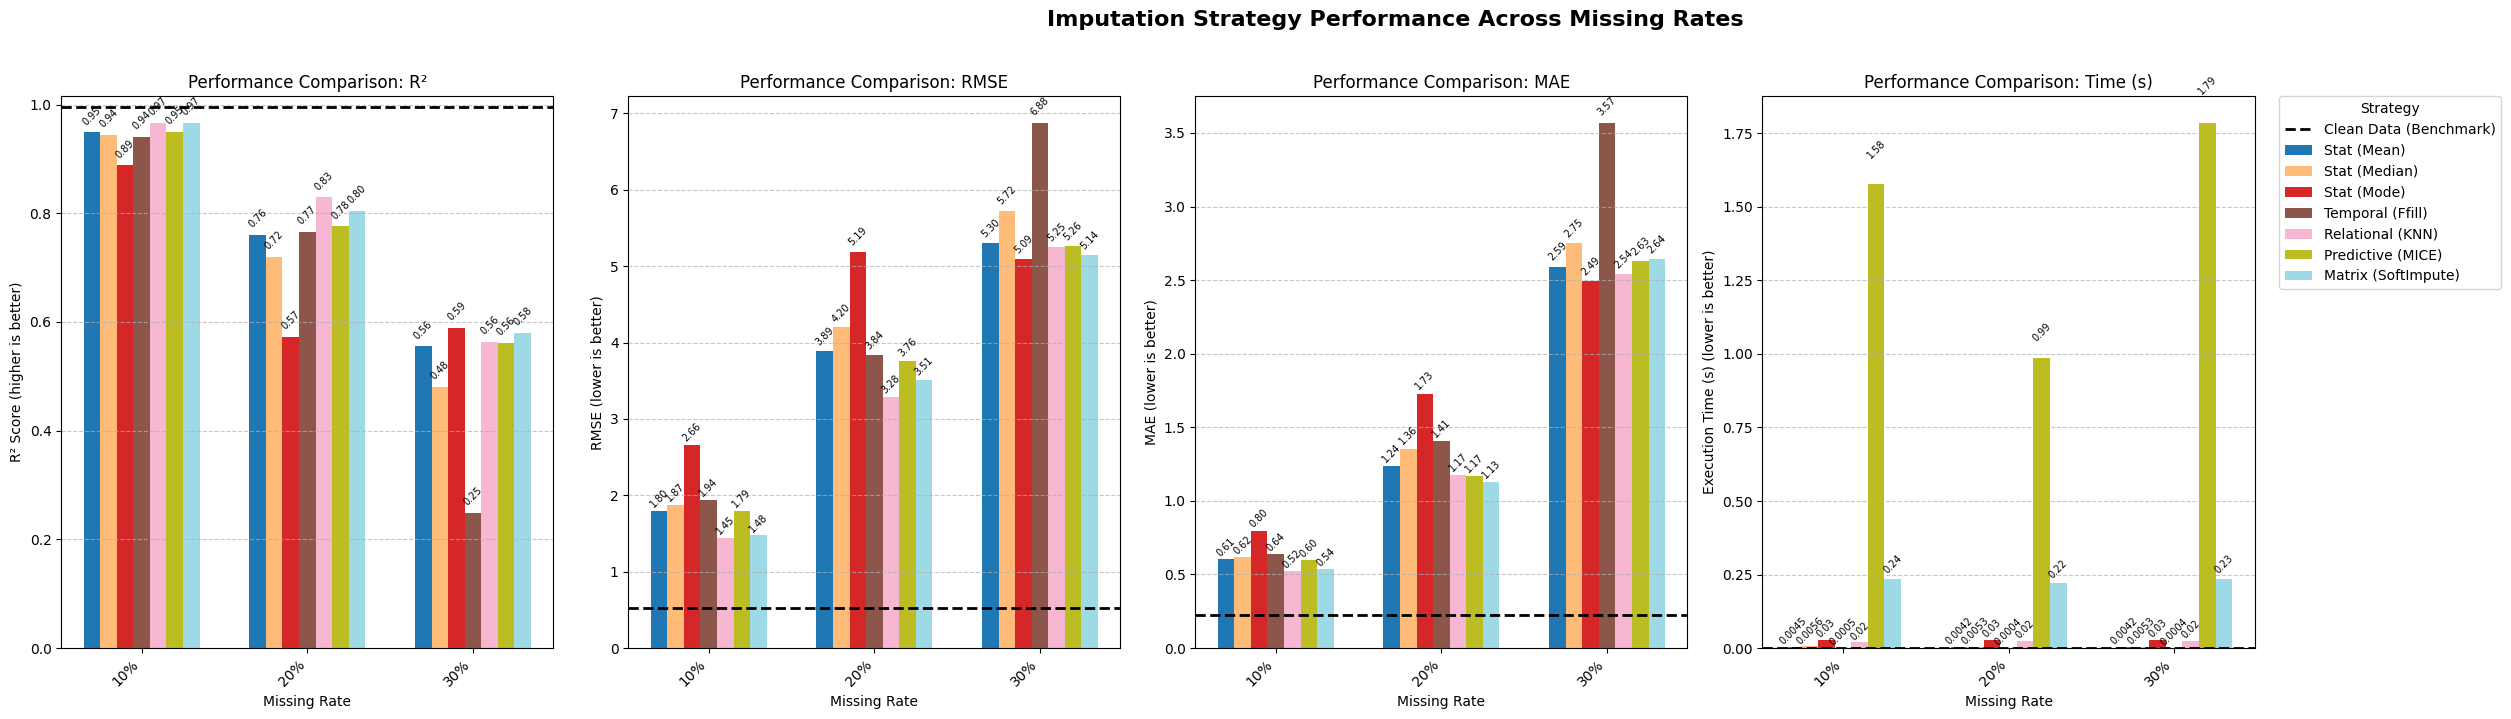

In [164]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for plotting
plot_df = results_df[results_df['Strategy'] != 'Corrupted (Unrepaired)']
strategies_to_plot = plot_df['Strategy'].unique().tolist()

# Remove 'Clean (Perfect Data)' from strategies for bar plots, keep it for reference
clean_data_strategy = plot_df[plot_df['Strategy'] == 'Clean (Perfect Data)'].iloc[0]
strategies_for_bars = [s for s in strategies_to_plot if s != 'Clean (Perfect Data)']

metrics = ['R²', 'RMSE', 'MAE', 'Time (s)'] # Added 'Time (s)'
metric_titles = {'R²': 'R² Score (higher is better)', 'RMSE': 'RMSE (lower is better)', 'MAE': 'MAE (lower is better)', 'Time (s)': 'Execution Time (s) (lower is better)'}

fig, axes = plt.subplots(1, 4, figsize=(28, 7), sharex=True) # Increased subplot count to 4
axes = axes.flatten()

rates = sorted(plot_df['Rate'].unique())
x = np.arange(len(rates))
width = 0.1 # Adjusted width based on number of strategies

# Define a color palette for the strategies
colors = plt.cm.get_cmap('tab20', len(strategies_for_bars))

for i, metric in enumerate(metrics):
    ax = axes[i]

    # Plot bars for each imputation strategy
    for j, strategy in enumerate(strategies_for_bars):
        strategy_data = plot_df[plot_df['Strategy'] == strategy]
        vals = [strategy_data[strategy_data['Rate'] == rate][metric].values[0] for rate in rates]

        # Adjust x-position for each group of bars
        bar_positions = x + (j - len(strategies_for_bars)/2 + 0.5) * width

        bars = ax.bar(bar_positions, vals, width, label=strategy, color=colors(j))

        # Add value labels on top of bars
        for bar, val in zip(bars, vals):
            # Adjust label positioning based on metric type (R2 can be negative, time is usually small)
            if metric == 'R²':
                label_y_offset = 0.01 if val > 0 else -0.01
            elif metric == 'Time (s)':
                # For time, only label if value is somewhat significant
                label_y_offset = 0.05 * bar.get_height() if bar.get_height() > 0.01 else 0.001
            else:
                label_y_offset = 0.01 * bar.get_height() if bar.get_height() > 0.1 else 0.01

            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + label_y_offset,
                    f'{val:.2f}' if metric != 'Time (s)' or val > 0.01 else f'{val:.4f}', # Show more precision for very small times
                    ha='center', va='bottom', fontsize=7, rotation=45)

    # Plot 'Clean (Perfect Data)' as a horizontal reference line
    clean_val = clean_data_strategy[metric]
    ax.axhline(y=clean_val, color='black', linestyle='--', linewidth=2, label='Clean Data (Benchmark)')

    ax.set_xlabel('Missing Rate')
    ax.set_ylabel(metric_titles[metric])
    ax.set_title(f'Performance Comparison: {metric}')
    ax.set_xticks(x)
    ax.set_xticklabels(rates, rotation=45, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if i == len(metrics) -1: # Only add legend to the last plot for better readability
        ax.legend(title='Strategy', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    else:
        ax.legend().set_visible(False) # Hide legend for other subplots

plt.suptitle('Imputation Strategy Performance Across Missing Rates', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend
plt.show()

## **11. Detailed Leaderboards**

Here are the detailed leaderboards for RMSE, MAE, R² scores, and Execution Time across different missing rates.

In [165]:
# --- LEADERBOARD GENERATION AND RANKING ---#

# --- 1. R² Score Leaderboard (Higher is Better) ---
print("\n" + "\u2014"*60)
print("LEADERBOARD: Strategy Utility (R² Score) by Missing Rate")
print("\u2014"*60)

# Pivot the results DataFrame to get R² scores for each strategy and missing rate
pivot_r2 = results_df.pivot(index="Strategy", columns="Rate", values="R²")

# Filter out 'Clean (Perfect Data)' and 'Corrupted (Unrepaired)' for internal ranking calculations,
# as these are benchmarks, not imputation strategies to be ranked.
strategies_r2 = pivot_r2[(pivot_r2.index != 'Clean (Perfect Data)') & (pivot_r2.index != 'Corrupted (Unrepaired)')].copy()

# Calculate individual ranks for each missing rate (ascending=False because higher R² is better)
strategies_r2['Rank_10%'] = strategies_r2['10%'].rank(ascending=False, method='average')
strategies_r2['Rank_20%'] = strategies_r2['20%'].rank(ascending=False, method='average')
strategies_r2['Rank_30%'] = strategies_r2['30%'].rank(ascending=False, method='average')

# Calculate an overall average rank across all missing rates for R²
strategies_r2['Overall_Rank_Avg'] = strategies_r2[['Rank_10%', 'Rank_20%', 'Rank_30%']].mean(axis=1)

# Sort strategies by their overall average R² rank (best performing first)
strategies_r2 = strategies_r2.sort_values(by='Overall_Rank_Avg', ascending=True)

# Prepare the DataFrame for display: show only rate-specific R² values and add a formatted 'Overall Rank'
pivot_r2_ranked = strategies_r2[['10%', '20%', '30%']].copy()
pivot_r2_ranked.insert(0, 'Overall Rank', [f'#{i+1}' for i in range(len(pivot_r2_ranked))])

# Add 'Clean (Perfect Data)' and 'Corrupted (Unrepaired)' back to the display with 'N/A' rank
clean_r2 = pivot_r2[pivot_r2.index == 'Clean (Perfect Data)'][['10%', '20%', '30%']].copy()
clean_r2.insert(0, 'Overall Rank', 'N/A')
corrupted_r2 = pivot_r2[pivot_r2.index == 'Corrupted (Unrepaired)'][['10%', '20%', '30%']].copy()
corrupted_r2.insert(0, 'Overall Rank', 'N/A')

# Concatenate all parts to form the final R² leaderboard display
pivot_r2_ranked = pd.concat([clean_r2, pivot_r2_ranked, corrupted_r2])
print(pivot_r2_ranked)

# --- 2. RMSE Leaderboard (Lower is Better) ---
print("\n" + "\u2014"*60)
print("LEADERBOARD: RMSE (Lower is Better) by Missing Rate")
print("\u2014"*60)

# Pivot the results DataFrame for RMSE scores
pivot_rmse = results_df.pivot(index="Strategy", columns="Rate", values="RMSE")

# Filter out 'Clean' and 'Corrupted' for ranking
strategies_rmse = pivot_rmse[(pivot_rmse.index != 'Clean (Perfect Data)') & (pivot_rmse.index != 'Corrupted (Unrepaired)')].copy()

# Calculate individual ranks for each missing rate (ascending=True because lower RMSE is better)
strategies_rmse['Rank_10%'] = strategies_rmse['10%'].rank(ascending=True, method='average')
strategies_rmse['Rank_20%'] = strategies_rmse['20%'].rank(ascending=True, method='average')
strategies_rmse['Rank_30%'] = strategies_rmse['30%'].rank(ascending=True, method='average')

# Calculate an overall average rank across all missing rates for RMSE
strategies_rmse['Overall_Rank_Avg'] = strategies_rmse[['Rank_10%', 'Rank_20%', 'Rank_30%']].mean(axis=1)

# Sort strategies by their overall average RMSE rank
strategies_rmse = strategies_rmse.sort_values(by='Overall_Rank_Avg', ascending=True)

# Prepare the DataFrame for display
pivot_rmse_ranked = strategies_rmse[['10%', '20%', '30%']].copy()
pivot_rmse_ranked.insert(0, 'Overall Rank', [f'#{i+1}' for i in range(len(pivot_rmse_ranked))])

# Add 'Clean' and 'Corrupted' back to the display with 'N/A' rank
clean_rmse = pivot_rmse[pivot_rmse.index == 'Clean (Perfect Data)'][['10%', '20%', '30%']].copy()
clean_rmse.insert(0, 'Overall Rank', 'N/A')
corrupted_rmse = pivot_rmse[pivot_rmse.index == 'Corrupted (Unrepaired)'][['10%', '20%', '30%']].copy()
corrupted_rmse.insert(0, 'Overall Rank', 'N/A')

# Concatenate all parts to form the final RMSE leaderboard display
pivot_rmse_ranked = pd.concat([clean_rmse, pivot_rmse_ranked, corrupted_rmse])
print(pivot_rmse_ranked)

# --- 3. MAE Leaderboard (Lower is Better) ---
print("\n" + "\u2014"*60)
print("LEADERBOARD: MAE (Lower is Better) by Missing Rate")
print("\u2014"*60)

# Pivot the results DataFrame for MAE scores
pivot_mae = results_df.pivot(index="Strategy", columns="Rate", values="MAE")

# Filter out 'Clean' and 'Corrupted' for ranking
strategies_mae = pivot_mae[(pivot_mae.index != 'Clean (Perfect Data)') & (pivot_mae.index != 'Corrupted (Unrepaired)')].copy()

# Calculate individual ranks for each missing rate (ascending=True because lower MAE is better)
strategies_mae['Rank_10%'] = strategies_mae['10%'].rank(ascending=True, method='average')
strategies_mae['Rank_20%'] = strategies_mae['20%'].rank(ascending=True, method='average')
strategies_mae['Rank_30%'] = strategies_mae['30%'].rank(ascending=True, method='average')

# Calculate an overall average rank across all missing rates for MAE
strategies_mae['Overall_Rank_Avg'] = strategies_mae[['Rank_10%', 'Rank_20%', 'Rank_30%']].mean(axis=1)

# Sort strategies by their overall average MAE rank
strategies_mae = strategies_mae.sort_values(by='Overall_Rank_Avg', ascending=True)

# Prepare the DataFrame for display
pivot_mae_ranked = strategies_mae[['10%', '20%', '30%']].copy()
pivot_mae_ranked.insert(0, 'Overall Rank', [f'#{i+1}' for i in range(len(pivot_mae_ranked))])

# Add 'Clean' and 'Corrupted' back to the display with 'N/A' rank
clean_mae = pivot_mae[pivot_mae.index == 'Clean (Perfect Data)'][['10%', '20%', '30%']].copy()
clean_mae.insert(0, 'Overall Rank', 'N/A')
corrupted_mae = pivot_mae[pivot_mae.index == 'Corrupted (Unrepaired)'][['10%', '20%', '30%']].copy()
corrupted_mae.insert(0, 'Overall Rank', 'N/A')

# Concatenate all parts to form the final MAE leaderboard display
pivot_mae_ranked = pd.concat([clean_mae, pivot_mae_ranked, corrupted_mae])
print(pivot_mae_ranked)

# --- 4. Execution Time Leaderboard (Lower is Better) ---
print("\n" + "\u2014"*60)
print("LEADERBOARD: Execution Time (Lower is Better) by Missing Rate")
print("\u2014"*60)

# Pivot the results DataFrame for Execution Time
pivot_time = results_df.pivot(index="Strategy", columns="Rate", values="Time (s)")

# Filter out 'Clean' and 'Corrupted' for ranking
strategies_time = pivot_time[(pivot_time.index != 'Clean (Perfect Data)') & (pivot_time.index != 'Corrupted (Unrepaired)')].copy()

# Calculate individual ranks for each missing rate (ascending=True because lower time is better)
strategies_time['Rank_10%'] = strategies_time['10%'].rank(ascending=True, method='average')
strategies_time['Rank_20%'] = strategies_time['20%'].rank(ascending=True, method='average')
strategies_time['Rank_30%'] = strategies_time['30%'].rank(ascending=True, method='average')

# Calculate an overall average rank across all missing rates for Time
strategies_time['Overall_Rank_Avg'] = strategies_time[['Rank_10%', 'Rank_20%', 'Rank_30%']].mean(axis=1)

# Sort strategies by their overall average time rank
strategies_time = strategies_time.sort_values(by='Overall_Rank_Avg', ascending=True)

# Prepare the DataFrame for display
pivot_time_ranked = strategies_time[['10%', '20%', '30%']].copy()
pivot_time_ranked.insert(0, 'Overall Rank', [f'#{i+1}' for i in range(len(pivot_time_ranked))])

# Add 'Clean' and 'Corrupted' back to the display with 'N/A' rank
clean_time = pivot_time[pivot_time.index == 'Clean (Perfect Data)'][['10%', '20%', '30%']].copy()
clean_time.insert(0, 'Overall Rank', 'N/A')
corrupted_time = pivot_time[pivot_time.index == 'Corrupted (Unrepaired)'][['10%', '20%', '30%']].copy()
corrupted_time.insert(0, 'Overall Rank', 'N/A')

# Concatenate all parts to form the final Execution Time leaderboard display
pivot_time_ranked = pd.concat([clean_time, pivot_time_ranked, corrupted_time])
print(pivot_time_ranked)

# --- 5. Overall Conclusive Leaderboard (Average Rank Across All Metrics) ---

# Combine the 'Overall_Rank_Avg' from each individual metric's strategies DataFrame.
# These DataFrames (strategies_r2, strategies_rmse, etc.) already have 'Clean' and 'Corrupted'
# filtered out for accurate ranking among imputation strategies.
combined_ranks = pd.DataFrame({
    'R2_Rank_Avg': strategies_r2['Overall_Rank_Avg'],
    'RMSE_Rank_Avg': strategies_rmse['Overall_Rank_Avg'],
    'MAE_Rank_Avg': strategies_mae['Overall_Rank_Avg'],
    'Time_Rank_Avg': strategies_time['Overall_Rank_Avg']
})

# Calculate the ultimate overall average rank by averaging the average ranks from each metric.
combined_ranks['Overall_Avg_Rank'] = combined_ranks.mean(axis=1)

# Sort by the overall average rank to get the conclusive leaderboard (lower average rank is better)
conclusive_leaderboard = combined_ranks.sort_values(by='Overall_Avg_Rank', ascending=True)

# Insert a formatted 'Overall Conclusive Rank' column for display
conclusive_leaderboard.insert(0, 'Overall Conclusive Rank', [f'#{i+1}' for i in range(len(conclusive_leaderboard))])

print("\n" + "\u2014"*60)
print("OVERALL CONCLUSIVE LEADERBOARD (Average Rank Across All Metrics)")
print("\u2014"*60)
print(conclusive_leaderboard)


————————————————————————————————————————————————————————————
LEADERBOARD: Strategy Utility (R² Score) by Missing Rate
————————————————————————————————————————————————————————————
Rate                   Overall Rank       10%       20%        30%
Strategy                                                          
Clean (Perfect Data)            N/A  0.995607  0.995607   0.995607
Relational (KNN)                 #1  0.966767  0.829219   0.562741
Matrix (SoftImpute)              #2  0.965484  0.804238   0.580565
Predictive (MICE)                #3  0.949070  0.775806   0.560859
Stat (Mean)                      #4  0.948756  0.759472   0.555028
Stat (Mode)                      #5  0.888023  0.572500   0.589048
Stat (Median)                    #6  0.944404  0.720347   0.480545
Temporal (Ffill)                 #7  0.940339  0.765964   0.249415
Corrupted (Unrepaired)          N/A -3.898668 -9.636312 -22.747906

————————————————————————————————————————————————————————————
LEADERBOARD: RMSE (Lo

### **12. Visualizing the Guess vs. The Truth**
This cell provides a direct visual comparison of actual target values against the predictions made after imputation by a select few strategies. It helps to intuitively understand how well each strategy reconstructs the underlying signal.

1.  **Ground Truth Plot**: The actual `y_test` values (first 60 samples) are plotted as a thick black line, representing the 'ACTUAL TRUTH'.
2.  **Candidate Strategies**: A list `candidates` is chosen for visual comparison, focusing on a few representative imputation methods.
3.  **Prediction Plots**: For each candidate strategy, the first 60 predicted values from the `prediction_samples` dictionary (which contains predictions at a 20% failure rate) are plotted as dashed lines. This allows for a direct visual assessment of how closely the imputed predictions track the true values.

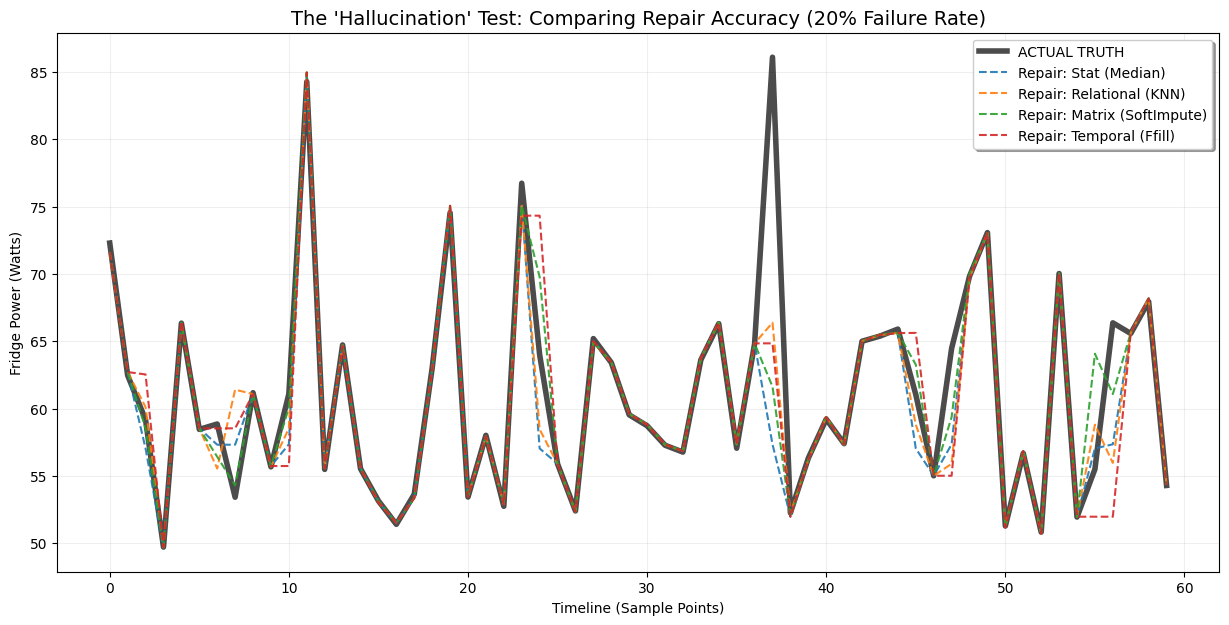

In [172]:
plt.figure(figsize=(15, 7))

# Plot the Ground Truth
plt.plot(y_test.values[:60], label='ACTUAL TRUTH', color='black', linewidth=4, alpha=0.7)

# Select key candidates for the visual battle
candidates = ["Stat (Median)", "Relational (KNN)", "Matrix (SoftImpute)", "Temporal (Ffill)"]

for c in candidates:
    plt.plot(prediction_samples[c][:60], label=f'Repair: {c}', linestyle='--', alpha=0.9)

plt.title("The 'Hallucination' Test: Comparing Repair Accuracy (20% Failure Rate)", fontsize=14)
plt.ylabel("Fridge Power (Watts)")
plt.xlabel("Timeline (Sample Points)")
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, alpha=0.2)
plt.show()